# トップリバー：予測モデル作成

In [1]:
import os
import numpy as np
import pandas as pd
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from pycaret.regression import *
from sklearn.metrics import r2_score, mean_absolute_percentage_error

In [2]:
### 変数設定 ###
#--ファイル
farm_list = "farm/topriver_farm.csv"
farm_data = "farm/topriver_data.csv"
remove_list = "farm/topriver_remove_list.csv"
weather_file = "weather/topriver/weather_{}.csv"
model_data = "farm/topriver_model_data.csv"

## 前処理と特徴量作成
- MLモデル学習用のデータセットを作成し、CSV出力する
- 一度CSV作成すれば、それ以降は当該CSVを読み込めば良い

In [3]:
### データ読み込み ###
#--圃場IDリスト読み込み
df_IDs = pd.read_csv(farm_list)
#--生育データ読み込み（レタスの品種に絞ったデータ）
df_farm = pd.read_csv(farm_data, parse_dates=['定植日','収穫日'])
#--除外リスト読み込み
df_remove = pd.read_csv(remove_list)
#--圃場IDを栽培データに結合
df_farm = pd.merge(df_farm, df_IDs.get(['圃場名','field_id']), on='圃場名', how='left')

#--分析で使用する気象データ読み込み
df_weather = {}
for fid in df_farm['field_id'].unique():
    dfw = pd.read_csv(weather_file.format(fid), parse_dates=['date'])
    df_weather[fid] = dfw

In [4]:
### データ前処理 ###
#--解析対象から除外するデータを削除
for index, row in df_remove.iterrows():
    group = row['栽培グループ名']
    field = row['圃場名']
    year = row['年度']
    df_farm = df_farm.query("not (栽培グループ名 == @group and 圃場名 == @field and 年度 == @year)").reset_index(drop=True)

#--『御代田地区：フレデリック』は2025年のデータしかないため除外
#--『富士見地区：グリーンブーケ』『富士見地区：フレデリック』は2024年で1圃場のデータしかないため除外
#--『富士見地区：TLE-567』は2024年をテストデータとする場合に学習データが2023年しかないため除外
exclude_groups = ['御代田地区：フレデリック', '富士見地区：グリーンブーケ', '富士見地区：フレデリック', '富士見地区：TLE-567']
df_farm = df_farm.query("栽培グループ名 not in @exclude_groups").reset_index(drop=True)

#--栽培グループ名を地区と品種に分割
df_farm[['地区','品種']] = df_farm['栽培グループ名'].str.split("：",expand=True)
#--栽培日数(収穫日-定植日)を計算
df_farm['栽培日数'] = (df_farm['収穫日']-df_farm['定植日']).dt.days
#--定植日＋経過日で各データの対象日を計算
df_farm['日付'] = df_farm['定植日'] + pd.to_timedelta(df_farm['経過日'], unit='D')
#--栽培日数よりも長い経過日は削除しておく
df_farm = df_farm.query("栽培日数 >= 経過日").reset_index(drop=True)
#--NDVI値がゼロは、欠損に変えておく
df_farm['NDVI値'] = df_farm['NDVI値'].mask(df_farm['NDVI値']==0, np.nan)

In [5]:
#--栽培グループ名ごとにデータが存在する年度を確認
for g, df in df_farm.groupby('栽培グループ名'):
    print(g, df['年度'].unique())

【新】御代田地区：ウィザード [2018 2019 2020 2022]
【新】御代田地区：スターレイ [2018 2019 2020 2021 2022 2023 2024]
富士見地区：ウィザード [2018 2019 2020 2021 2022 2023 2024 2025]
富士見地区：エスコート [2021 2022 2023 2024 2025]
富士見地区：オーウェン [2018 2019 2020 2021 2022]
富士見地区：サマーガイ [2018 2019]
富士見地区：スターレイ [2018 2019 2020 2021 2022 2023 2024]
富士見地区：ツインデル [2018 2019]
富士見地区：ハイジ [2018 2019 2020 2021 2022]
富士見地区：ファンファーレ [2018 2021 2022 2023 2024 2025]
富士見地区：フリフリッカー [2018 2019 2020 2021]
富士見地区：ペネトレイト [2019 2020 2021 2022 2023 2024 2025]
富士見地区：ルシナ66 [2022 2023 2024]
御代田地区：ウィザード [2019 2020 2022 2023]
御代田地区：エスコート [2018 2019 2020 2021 2022 2023 2024 2025]
御代田地区：スターレイ [2018 2019 2020 2021 2022 2023 2024 2025]
御代田地区：ハイジ [2021 2022 2023]
御代田地区：ファンファーレ [2018 2019 2020 2021 2022 2023 2024]
御代田地区：ペネトレイト [2019 2020 2021 2022 2023 2024 2025]
御代田地区：ルシナ66 [2020 2021 2022 2023 2024]
東御地区：ウィザード [2018 2019 2020 2021 2022 2023 2024 2025]
東御地区：スターレイ [2018 2019 2020 2021 2022 2023 2024 2025]


In [6]:
#--年度ごとにデータが存在する栽培グループ数を確認
for g, df in df_farm.groupby('年度'):
    print(g, len(df['栽培グループ名'].unique()))

2018 15
2019 17
2020 16
2021 17
2022 19
2023 16
2024 14
2025 9


In [7]:
### NDVI異常値処理 ###
# 栽培グループごとに過去のNDVIデータをシグモイド曲線でフィッティングする
# 曲線フィッティングの残差の標準偏差を計算し、±2σを超えるNDVIを異常値とする
# 異常値処理方法は、NDVIを±2σに乗せるように補正する（クリッピングする）

#--シグモイド関数
def logistic4(x, a, K, b, x0):
    return a + (K - a) / (1.0 + np.exp(-b * (x - x0)))

#--シグモイド関数でフィッティングした基準曲線と±2σの帯を表示
modified = []
for group, df_group in df_farm.groupby('栽培グループ名'):
    #--シグモイド曲線でフィッティング
    x = df_group.dropna()['経過日'].values
    y = df_group.dropna()['NDVI値'].values

    a0  = y.min()  # 初期NDVI
    K0  = y.max()  # 最大NDVI
    x0_ = x.mean() # 立ち上がり中心
    b0  = 0.1      # 傾き（0.1〜0.2くらいから試す）
    p0 = [a0, K0, b0, x0_] # 初期パラメータ

    params, cov = curve_fit(logistic4, x, y, p0=p0, maxfev=10000)

    #--残差と標準偏差σを計算
    y_pred = logistic4(x, *params)
    residuals = y - y_pred
    sigma = np.std(residuals)
    #--経過日＝100日の値を平均的なNDVIの最大値とする
    peak_ndvi = logistic4(100, *params)

    #--基準曲線±2σから外れるNDVIを補正
    df_group['base'] = logistic4(df_group['経過日'], *params)
    upper_limit = df_group['base'] + 2 * sigma
    lower_limit = df_group['base'] - 2 * sigma
    df_group['NDVI値'] = df_group['NDVI値'].clip(lower=lower_limit, upper=upper_limit)
    df_group['remain_NDVI'] = (peak_ndvi - df_group['NDVI値']).clip(lower=0)
    modified.append(df_group.drop(columns=['base']))

df_farm = pd.concat(modified, ignore_index=True)

In [8]:
### 気象データの特徴量 ###
#--NDVIが欠損する行は、学習データに使用しない
df_ml = df_farm.dropna(subset=['NDVI値']).reset_index(drop=True)

#--定植してから当該日までの気象要素の積算値
# GDDはTbaseが2度・5度など情報があり、両方を計算しておく
# 上限温度25度も考慮する
wx_sum_list = []
wx_cols = None
for index, row in df_ml.iterrows():
    fid = row['field_id']
    s_date = row['定植日']
    e_date = row['日付']
    df = df_weather[fid].query("date >= @s_date and date < @e_date").reset_index(drop=True)
    df['TMP_GDD2'] = (df['TMP_mea'] - 2).clip(lower=0, upper=25).round(2)
    df['TMP_GDD5'] = (df['TMP_mea'] - 5).clip(lower=0, upper=25).round(2)
    df['TmulGSR'] = (df['TMP_mea'] * np.log(df['GSR']*23.9)).round(2)
    df['RA_days'] = (df['APCPRA'] >= 0.1).astype(int)
    sr = df.set_index('date').sum(axis=0).round(2)
    if wx_cols is None:
        wx_cols = sr.index.tolist()
    wx_sum_list.append(sr.tolist())
df_wx_sum = pd.DataFrame(wx_sum_list, columns=wx_cols)

#--元のデータに気象データを結合
df_ml = pd.concat([df_ml, df_wx_sum], axis=1).reset_index(drop=True)

#--気象要素によっては平均値を使う
df_ml['RH_ave'] = (df_ml['RH'] / df_ml['経過日']).round(2)
df_ml['WIND_ave'] = (df_ml['WIND'] / df_ml['経過日']).round(2)
df_ml['TMP_mea_ave'] = (df_ml['TMP_mea'] / df_ml['経過日']).round(2)
df_ml['SSD_ave'] = (df_ml['SSD'] / df_ml['経過日']).round(2)

#--日較差の合計
df_ml['TMP_diff'] = (df_ml['TMP_max'] - df_ml['TMP_min']).round(2)

In [9]:
#--当該日から一定の日数後までの気象要素の積算値（未来の情報）
for d in range(5,35,5):
    wx_sum_list = []
    wx_cols = None

    for index, row in df_ml.iterrows():
        fid = row['field_id']
        s_date = row['日付']
        e_date = s_date + pd.Timedelta(days=d)
        df = df_weather[fid].query("date >= @s_date and date < @e_date").reset_index(drop=True)
        df['TMP_GDD2'] = (df['TMP_mea'] - 2).clip(lower=0, upper=25).round(2)
        df['TMP_GDD5'] = (df['TMP_mea'] - 5).clip(lower=0, upper=25).round(2)
        df['TmulGSR'] = (df['TMP_mea'] * np.log(df['GSR']*23.9)).round(2)
        df['RA_days'] = (df['APCPRA'] >= 0.1).astype(int)
        sr = df.set_index('date').sum(axis=0).round(2)
        if wx_cols is None:
            wx_cols = (sr.index + f'_{d:02d}').tolist()
        wx_sum_list.append(sr.tolist())
    df_wx_sum = pd.DataFrame(wx_sum_list, columns=wx_cols)

    #--元のデータに気象データを結合
    df_ml = pd.concat([df_ml, df_wx_sum], axis=1).reset_index(drop=True)

    #--気象要素によっては平均値を使う
    df_ml[f'RH_ave_{d:02d}'] = (df_ml[f'RH_{d:02d}'] / d).round(2)
    df_ml[f'WIND_ave_{d:02d}'] = (df_ml[f'WIND_{d:02d}'] / d).round(2)
    df_ml[f'TMP_mea_ave_{d:02d}'] = (df_ml[f'TMP_mea_{d:02d}'] / d).round(2)
    df_ml[f'SSD_ave_{d:02d}'] = (df_ml[f'SSD_{d:02d}'] / d).round(2)

    #--日較差の合計
    df_ml[f'TMP_diff_{d:02d}'] = (df_ml[f'TMP_max_{d:02d}'] - df_ml[f'TMP_min_{d:02d}']).round(2)

In [10]:
### 作物に関する特徴量 ###
#--作期
df_ml['planting_days'] = df_ml['定植日'].dt.dayofyear
df_ml['planting_month'] = df_ml['定植日'].dt.month

# #--品種ごとの平均的な栽培日数（テストデータの2025年を除く）
# df_stats = (df_ml
#     .query("年度 != 2025")
#     .drop_duplicates(subset=['栽培グループ名','年度','圃場名'])
#     .groupby('栽培グループ名')
#     .aggregate({'栽培日数':['mean','std']})
# ).round(1)
# df_stats.columns = ['grow_days_mean', 'grow_days_std']
#
# df_ml = pd.merge(df_ml, df_stats, on='栽培グループ名', how='left')
# df_ml['remain_days'] = (df_ml['grow_days_mean'] - df_ml['経過日']).round(2)

In [11]:
#--ターゲット変数：当該日から何日後が収穫日か
df_ml['Target_Days'] = df_ml['栽培日数'] - df_ml['経過日']

In [12]:
#--モデル学習・検証用データセット出力
df_ml.to_csv(model_data, index=False)

## モデル学習
- PyCaretを用いたMLモデルの学習を行う

In [3]:
### データ読み込み ###
#--ML学習用データセット読み込み
df_ml = pd.read_csv(model_data)

#--2024年をテストデータとする場合、2025年は除外しておく
df_ml = df_ml.query("年度 != 2025").reset_index(drop=True)

In [4]:
### 追加の前処理 ###
#--品種ごとの平均的な栽培日数（テストデータの年を除く）
# 自らの年度を含まずに栽培日数の平均値を求める
test_year = 2024
# test_year = 2025

df_stats = pd.DataFrame()
for y in df_ml['年度'].unique():
    df = (df_ml
        .query("年度 != @test_year")
        .query("年度 != @y")
        .drop_duplicates(subset=['栽培グループ名','年度','圃場名'])
        .groupby('栽培グループ名')
        .aggregate({'栽培日数':['mean','std']})
    ).round(1)
    df.columns = ['grow_days_mean', 'grow_days_std']
    df['年度'] = y
    df_stats = pd.concat([df_stats, df])

df_ml = pd.merge(df_ml, df_stats.fillna(0), on=['栽培グループ名','年度'], how='left')
df_ml['remain_days'] = (df_ml['grow_days_mean'] - df_ml['経過日']).round(2)

#--経過日=0日だと気象要素の平均値が定義できないためNaNになっている→ゼロで補完
df_ml.fillna(0, inplace=True)

In [5]:
### 学習前準備 ###
# #--カラム名一覧表示
# for i in range(len(df_ml.columns)//10 + 1):
#     print(df_ml.columns[i*10:(i+1)*10].tolist())

#--目的変数と説明変数の設定
target_col = 'Target_Days'
feature_cols = [
    '経過日', 'NDVI値', 'remain_NDVI', 
    'TMP_mea', 'APCPRA', 'GSR', 'TMP_GDD2', 'TMP_GDD5', 'TmulGSR', 'RA_days', 
    'TMP_mea_05', 'APCPRA_05', 'GSR_05', 'TMP_GDD2_05', 'TMP_GDD5_05', 'TmulGSR_05', 'RA_days_05',
    'TMP_mea_10', 'APCPRA_10', 'GSR_10', 'TMP_GDD2_10', 'TMP_GDD5_10', 'TmulGSR_10', 'RA_days_10',
    'TMP_mea_15', 'APCPRA_15', 'GSR_15', 'TMP_GDD2_15', 'TMP_GDD5_15', 'TmulGSR_15', 'RA_days_15',
    'TMP_mea_20', 'APCPRA_20', 'GSR_20', 'TMP_GDD2_20', 'TMP_GDD5_20', 'TmulGSR_20', 'RA_days_20',
    'TMP_mea_25', 'APCPRA_25', 'GSR_25', 'TMP_GDD2_25', 'TMP_GDD5_25', 'TmulGSR_25', 'RA_days_25',
    'TMP_mea_30', 'APCPRA_30', 'GSR_30', 'TMP_GDD2_30', 'TMP_GDD5_30', 'TmulGSR_30', 'RA_days_30',
    'planting_month', 'grow_days_mean', 'grow_days_std', 'remain_days',
]
ignore_cols = [col for col in df_ml.columns if col not in feature_cols + [target_col]]
print(f'Feature cols: {len(feature_cols)}, Ignore cols: {len(ignore_cols)}')

categorical_cols = ['planting_month']
for col in categorical_cols:
    df_ml[col] = pd.Categorical(df_ml[col])

#--Train/Test Split
TRAIN = df_ml.query("年度 != @test_year").reset_index(drop=True)
TEST = df_ml.query("年度 == @test_year").reset_index(drop=True)
print(f'Train samples: {TRAIN.shape[0]}, Test samples: {TEST.shape[0]}')

# X_train = TRAIN[feature_cols]
# y_train = TRAIN[target_col]
# X_test = TEST[feature_cols]
# y_test = TEST[target_col]

Feature cols: 56, Ignore cols: 116
Train samples: 6449, Test samples: 1273


In [6]:
#--PyCaretのセットアップ
groups = TRAIN['年度']
fold_num = TRAIN['年度'].nunique()

reg = setup(
    data = TRAIN,
    target = target_col,
    ignore_features = ignore_cols,
    categorical_features = categorical_cols,
    session_id = 42,
    fold_strategy='groupkfold',
    fold_groups=groups,
    fold=fold_num,
    data_split_shuffle=False,
    fold_shuffle=False,
    verbose=False,
    n_jobs = -1
)

In [7]:
### MLモデル学習 ###
#--複数のアルゴリズム比較
best = compare_models()

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
et,Extra Trees Regressor,2.6754,12.2715,3.4954,0.9515,0.3330,0.2462,0.4950
catboost,CatBoost Regressor,2.6986,12.5098,3.5226,0.9509,0.3323,0.2383,1.6533
lightgbm,Light Gradient Boosting Machine,2.7294,12.9591,3.5899,0.9489,0.3252,0.2351,0.3033
lasso,Lasso Regression,2.7723,12.9484,3.5864,0.9486,0.3676,0.2954,0.2267
en,Elastic Net,2.7939,12.9924,3.5925,0.9484,0.3694,0.2982,0.0467
llar,Lasso Least Angle Regression,2.8015,13.1505,3.6128,0.9478,0.3710,0.2994,0.0167
gbr,Gradient Boosting Regressor,2.7861,13.2699,3.6313,0.9477,0.3319,0.2427,0.6700
rf,Random Forest Regressor,2.8523,13.7216,3.6978,0.9458,0.3389,0.2542,1.4817
br,Bayesian Ridge,2.9271,14.3658,3.7689,0.9432,0.3841,0.3030,0.0200
xgboost,Extreme Gradient Boosting,2.9262,14.8865,3.8455,0.9414,0.3628,0.2722,0.1367


In [8]:
#--Lasso回帰モデル作成
print("Lasso回帰")
model_lasso = create_model('lasso')

#--Bayesian Ridge回帰モデル作成
print("Bayesian Ridge")
model_br = create_model('br')

#--Extra Tree Regressorモデル作成
print("Extra Tree Regressor")
model_etr = create_model('et')

#--ランダムフォレストモデル作成
print("Random Forest")
model_rfr = create_model('rf')

#--LightGBMモデル作成
print("LightGBM")
model_lgbm = create_model('lightgbm')

#--CatBoostモデル作成
print("CatBoost")
model_cat = create_model('catboost')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.0268,14.4611,3.8028,0.9411,0.3061,0.2468
1,2.6135,15.8996,3.9874,0.9343,0.3799,0.2750
2,2.4393,9.3888,3.0641,0.9656,0.3669,0.2926
3,2.7866,13.3991,3.6605,0.9511,0.3557,0.2943
4,2.8162,11.6342,3.4109,0.9574,0.4022,0.2827
5,2.9515,12.9079,3.5928,0.9422,0.3946,0.3806
Mean,2.7723,12.9484,3.5864,0.9486,0.3676,0.2954
Std,0.1980,2.0656,0.2935,0.0106,0.0316,0.0413


Bayesian Ridge


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.5518,18.2454,4.2715,0.9257,0.3730,0.2824
1,2.3672,14.6313,3.8251,0.9395,0.3535,0.2342
2,2.3379,9.1027,3.0171,0.9666,0.3512,0.2629
3,3.1693,17.0432,4.1283,0.9378,0.4234,0.3553
4,3.1567,13.9603,3.7364,0.9489,0.4138,0.3072
5,2.9795,13.2117,3.6348,0.9408,0.3895,0.3757
Mean,2.9271,14.3658,3.7689,0.9432,0.3841,0.3030
Std,0.4407,2.9294,0.4019,0.0125,0.0277,0.0497


Extra Tree Regressor


...

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.1445,15.6687,3.9584,0.9362,0.2729,0.1964
1,2.4320,13.1485,3.6261,0.9456,0.3129,0.2135
2,2.6559,11.2384,3.3524,0.9588,0.3436,0.2572
3,2.9628,15.8274,3.9784,0.9422,0.3683,0.2520
4,2.9660,12.7595,3.5721,0.9533,0.3553,0.2590
5,2.9524,13.6874,3.6996,0.9387,0.3802,0.3474
Mean,2.8523,13.7216,3.6978,0.9458,0.3389,0.2542
Std,0.2366,1.6149,0.2187,0.0080,0.0363,0.0478


LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.9649,13.9348,3.7329,0.9433,0.2682,0.1886
1,2.4023,13.4664,3.6697,0.9443,0.3102,0.1945
2,2.4415,9.6383,3.1046,0.9647,0.3222,0.2274
3,2.8927,15.8973,3.9871,0.9420,0.3688,0.2456
4,2.9124,12.6741,3.5601,0.9536,0.3248,0.2301
5,2.7623,12.1434,3.4847,0.9456,0.3571,0.3247
Mean,2.7294,12.9591,3.5899,0.9489,0.3252,0.2351
Std,0.2261,1.8981,0.2684,0.0080,0.0327,0.0448


CatBoost


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.9596,13.7763,3.7116,0.9439,0.2621,0.1838
1,2.4148,12.9768,3.6023,0.9464,0.3121,0.2026
2,2.4692,10.0316,3.1673,0.9632,0.3309,0.2270
3,3.0740,16.6392,4.0791,0.9393,0.4035,0.2696
4,2.7690,11.4420,3.3826,0.9581,0.3269,0.2251
5,2.5051,10.1926,3.1926,0.9544,0.3584,0.3215
Mean,2.6986,12.5098,3.5226,0.9509,0.3323,0.2383
Std,0.2532,2.2922,0.3180,0.0084,0.0431,0.0455


In [9]:
#--ハイパーパラメータのチューニング
print("Lasso回帰")
tuned_lasso = tune_model(model_lasso, n_iter=50, optimize='MAE')
print("Bayesian Ridge")
tuned_br = tune_model(model_br, n_iter=50, optimize='MAE')
print("Extra Tree Regressor")
tuned_etr = tune_model(model_etr, n_iter=50, optimize='MAE')
print("Random Forest")
tuned_rfr = tune_model(model_rfr, n_iter=50, optimize='MAE')
print("LightGBM")
tuned_lgbm = tune_model(model_lgbm, n_iter=50, optimize='MAE')
print("CatBoost")
tuned_cat = tune_model(model_cat, n_iter=50, optimize='MAE')

Lasso回帰


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.9874,14.2230,3.7713,0.9421,0.3014,0.2437
1,2.6433,16.0816,4.0102,0.9335,0.3850,0.2792
2,2.4558,9.5015,3.0825,0.9652,0.3696,0.2959
3,2.8145,13.6035,3.6883,0.9503,0.3594,0.2966
4,2.8400,11.8707,3.4454,0.9565,0.4041,0.2844
5,2.9223,12.7251,3.5672,0.9430,0.3977,0.3785
Mean,2.7772,13.0009,3.5941,0.9484,0.3695,0.2964
Std,0.1788,2.0391,0.2881,0.0103,0.0341,0.0407


Fitting 6 folds for each of 50 candidates, totalling 300 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
Bayesian Ridge


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.5520,18.2451,4.2714,0.9257,0.3729,0.2824
1,2.3675,14.6336,3.8254,0.9395,0.3537,0.2343
2,2.3378,9.1014,3.0169,0.9666,0.3513,0.2629
3,3.1672,17.0132,4.1247,0.9379,0.4233,0.3552
4,3.1566,13.9589,3.7362,0.9489,0.4138,0.3072
5,2.9793,13.2091,3.6344,0.9409,0.3895,0.3758
Mean,2.9267,14.3602,3.7682,0.9433,0.3841,0.3030
Std,0.4404,2.9254,0.4015,0.0125,0.0276,0.0496


Fitting 6 folds for each of 50 candidates, totalling 300 fits
Extra Tree Regressor


...

Fitting 6 folds for each of 50 candidates, totalling 300 fits
LightGBM


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,2.9242,13.7512,3.7083,0.9440,0.2645,0.1931
1,2.3060,12.5079,3.5367,0.9483,0.3066,0.1860
2,2.5081,10.0480,3.1699,0.9632,0.3223,0.2286
3,2.8467,14.9558,3.8673,0.9454,0.3685,0.2537
4,2.8086,11.7053,3.4213,0.9571,0.3277,0.2211
5,2.6027,10.9073,3.3026,0.9512,0.3288,0.2955
Mean,2.6660,12.3126,3.5010,0.9515,0.3197,0.2297
Std,0.2153,1.6616,0.2358,0.0067,0.0310,0.0370


Fitting 6 folds for each of 50 candidates, totalling 300 fits
CatBoost


,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,3.0458,14.1807,3.7657,0.9423,0.2697,0.1968
1,2.2768,11.8225,3.4384,0.9511,0.3080,0.1966
2,2.5409,10.5344,3.2457,0.9614,0.3467,0.2409
3,2.7221,14.2307,3.7724,0.9481,0.3652,0.2584
4,2.9568,12.4848,3.5334,0.9543,0.3425,0.2459
5,2.6350,11.0875,3.3298,0.9504,0.3725,0.3273
Mean,2.6962,12.3901,3.5142,0.9512,0.3341,0.2443
Std,0.2564,1.4181,0.2009,0.0058,0.0353,0.0440


Fitting 6 folds for each of 50 candidates, totalling 300 fits


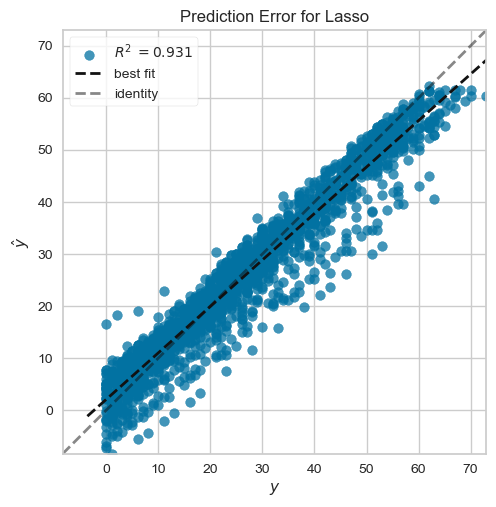

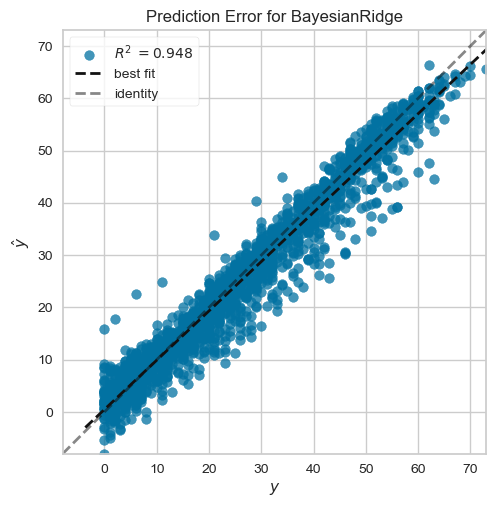

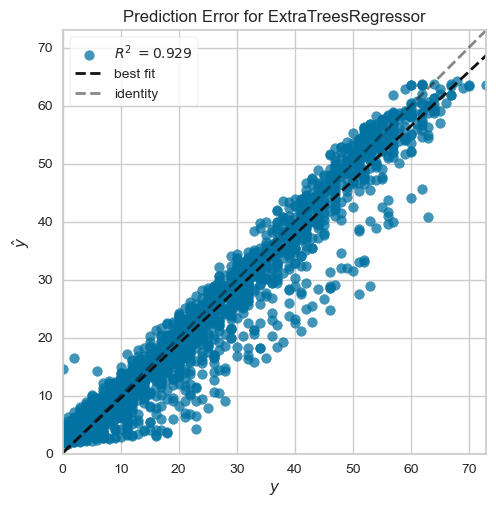

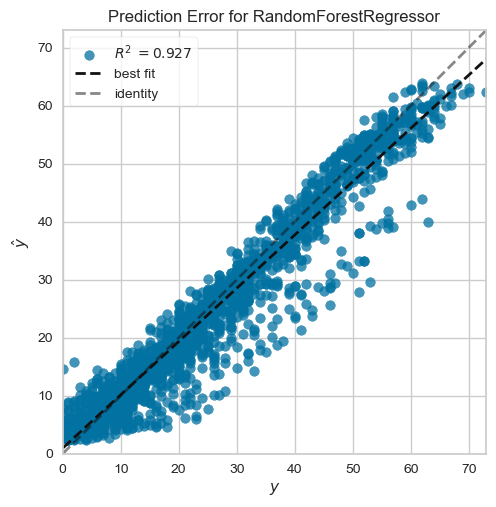

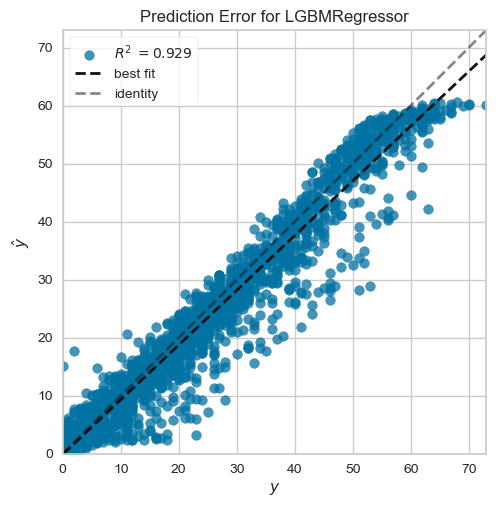

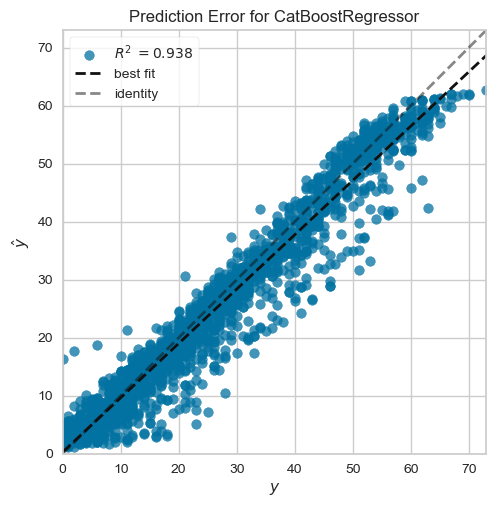

In [10]:
#--予測誤差プロット
plot_model(tuned_lasso, plot='error')
plot_model(tuned_br, plot='error')
plot_model(tuned_etr, plot='error')
plot_model(tuned_rfr, plot='error')
plot_model(tuned_lgbm, plot='error')
plot_model(tuned_cat, plot='error')

In [11]:
#--最終モデルの確定
final_lasso = finalize_model(tuned_lasso)
final_br = finalize_model(tuned_br)
final_etr = finalize_model(tuned_etr)
final_rfr = finalize_model(tuned_rfr)
final_lgbm = finalize_model(tuned_lgbm)
final_cat = finalize_model(tuned_cat)

In [12]:
#--テストデータで予測・評価（収穫日まで30日以内）
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST.query("Target_Days <= 30"))
print("Bayesian Ridge")
pred_br = predict_model(final_br, data=TEST.query("Target_Days <= 30"))
print("Extra Tree Regressor")
pred_etr = predict_model(final_etr, data=TEST.query("Target_Days <= 30"))
print("Random Forest")
pred_rfr = predict_model(final_rfr, data=TEST.query("Target_Days <= 30"))
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST.query("Target_Days <= 30"))
print("CatBoost")
pred_cat = predict_model(final_cat, data=TEST.query("Target_Days <= 30"))

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,2.4691,9.5959,3.0977,0.8763,0.3810,0.3381


Bayesian Ridge


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,2.4934,10.4263,3.2290,0.8656,0.3833,0.3157


Extra Tree Regressor


...

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.3385,8.9875,2.9979,0.8841,0.4206,0.3130


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2.1833,8.2487,2.8721,0.8936,0.3659,0.2611


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
CatBoost


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,2.3989,9.2079,3.0344,0.8813,0.3941,0.2904


In [13]:
#--テストデータで予測・評価
print("Lasso回帰")
pred_lasso = predict_model(final_lasso, data=TEST)
print("Bayesian Ridge")
pred_br = predict_model(final_br, data=TEST)
print("Extra Tree Regressor")
pred_etr = predict_model(final_etr, data=TEST)
print("Random Forest")
pred_rfr = predict_model(final_rfr, data=TEST)
print("LightGBM")
pred_lgbm = predict_model(final_lgbm, data=TEST)
print("CatBoost")
pred_cat = predict_model(final_cat, data=TEST)

Lasso回帰


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Lasso Regression,2.3866,9.0462,3.0077,0.9609,0.3037,0.2294


Bayesian Ridge


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Bayesian Ridge,2.5446,11.0984,3.3314,0.9520,0.3064,0.2184


Extra Tree Regressor


...

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Random Forest Regressor,2.3223,8.8698,2.9782,0.9617,0.3348,0.2141


LightGBM


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,Light Gradient Boosting Machine,2.2949,8.9730,2.9955,0.9612,0.2926,0.1841


[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.6, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6
CatBoost


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE
0,CatBoost Regressor,2.4267,9.4678,3.0770,0.9591,0.3143,0.2021


In [14]:
#--Lasso回帰の回帰係数をチェック
# reg = setup(
#     data = TRAIN,
#     target = target_col,
#     ignore_features = ignore_cols,
#     categorical_features = categorical_cols,
#     verbose=False,
#     session_id = 42,
# )

coef = final_lasso.coef_
intercept = final_lasso.intercept_
feature_names = get_config('X_train_transformed').columns

# DataFrameを作成
lasso_coef = pd.DataFrame({
    'Feature': np.append(feature_names, 'Intercept'),
    'Coefficient': np.append(coef, intercept)
})
display(lasso_coef.query("Coefficient != 0"))

,Feature,Coefficient
0,経過日,-0.008404
3,TMP_mea,-0.049159
4,APCPRA,0.003720
5,GSR,-0.016161
7,TMP_GDD5,0.006089
8,TmulGSR,0.004089
22,TmulGSR_10,-0.000597
26,GSR_15,-0.011808
29,TmulGSR_15,0.000014
31,TMP_mea_20,-0.013816


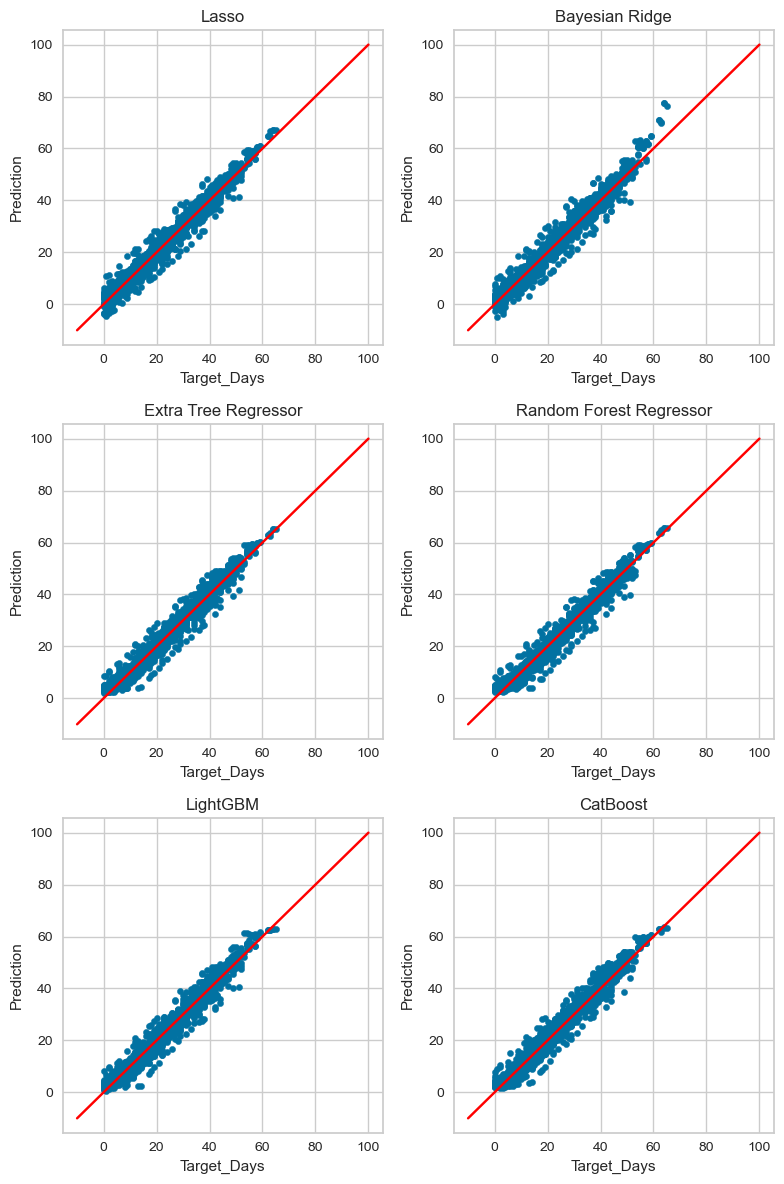

In [15]:
#--予測結果の散布図表示
result = [pred_lasso, pred_br, pred_etr, pred_rfr, pred_lgbm, pred_cat]
model_names = ['Lasso', 'Bayesian Ridge', 'Extra Tree Regressor', 'Random Forest Regressor', 'LightGBM', 'CatBoost']

fig = plt.figure(figsize=(8,12))
for model, result in zip(model_names, result):
    ax = fig.add_subplot(3, 2, model_names.index(model)+1)
    result.plot.scatter(x='Target_Days', y='prediction_label', ax=ax)
    ax.plot([-10,100], [-10,100], color='red')
    ax.set_ylabel('Prediction')
    ax.set_title(model)
plt.tight_layout()
plt.show()

,MAE,RMSE,R2,MAPE
0,2.907777,3.513399,0.946629,3.148628e+14


,MAE,RMSE,R2,MAPE
0,3.031858,3.664422,0.826863,5.067261e+14


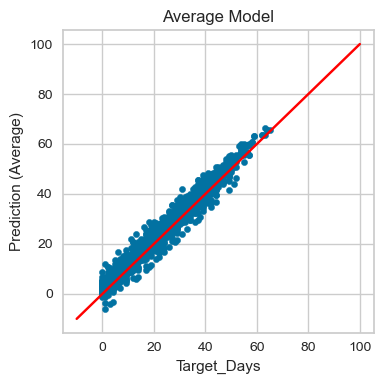

In [16]:
### 過去平均値モデル (ベンチマーク) ###
#--過去の平均値で予測
df_ave_model = pd.DataFrame({
    "MAE":[((TEST['remain_days'] - TEST['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST['remain_days'] - TEST['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST['Target_Days'], TEST['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST['Target_Days'], TEST['remain_days'])]
})
display(df_ave_model)

#--収穫日30日以内に絞った場合
TEST30 = TEST.query("Target_Days <= 30")
df_ave_model30 = pd.DataFrame({
    "MAE":[((TEST30['remain_days'] - TEST30['Target_Days']).abs()).mean()],
    "RMSE":[np.sqrt(((TEST30['remain_days'] - TEST30['Target_Days'])**2).mean())],
    "R2":[r2_score(TEST30['Target_Days'], TEST30['remain_days'])],
    "MAPE": [mean_absolute_percentage_error(TEST30['Target_Days'], TEST30['remain_days'])]
})
display(df_ave_model30)

#--散布図で可視化
fig = plt.figure(figsize=(4,4))
ax = fig.add_subplot(1, 1, 1)
TEST.plot.scatter(x='Target_Days', y='remain_days', ax=ax)
ax.plot([-10,100], [-10,100], color='red')
ax.set_ylabel('Prediction (Average)')
ax.set_title('Average Model')
plt.tight_layout()
plt.show()

In [17]:
#--MAPEのみTarget＿Days=0を除外して計算
df = TEST.query("Target_Days != 0")
print(((df['Target_Days'] - df['remain_days']).abs()/df['Target_Days']).mean())
df = TEST30.query("Target_Days != 0")
print(((df['Target_Days'] - df['remain_days']).abs()/df['Target_Days']).mean())

0.2718464049846051
0.4005940624285861


In [18]:
#--学習済みモデルの保存
save_dir = f"model/{test_year}"
os.makedirs(save_dir, exist_ok=True)

save_model(final_lasso, f"{save_dir}/topriver_lasso_model")
save_model(final_br, f"{save_dir}/topriver_br_model")
save_model(final_etr, f"{save_dir}/topriver_etr_model")
save_model(final_rfr, f"{save_dir}/topriver_rfr_model")
save_model(final_lgbm, f"{save_dir}/topriver_lgbm_model")
save_model(final_cat, f"{save_dir}/topriver_cat_model")

Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved
Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(include=['経過日', 'NDVI値', 'remain_NDVI',
                                              'TMP_mea', 'APCPRA', 'GSR',
                                              'TMP_GDD2', 'TMP_GDD5', 'TmulGSR',
                                              'RA_days', 'TMP_mea_05',
                                              'APCPRA_05', 'GSR_05',
                                              'TMP_GDD2_05', 'TMP_GDD5_05',
                                              'TmulGSR_05', 'RA_days_05',
                                              'TMP_mea_10', 'APCPRA_10',
                                              'GSR_10', 'TMP_GDD2_10',
                                              'TMP_GDD5_10', 'TmulGSR_10...
                                     transformer=SimpleImputer(strategy='most_frequent'))),
                 ('onehot_encoding',
                  TransformerWrapper(include=['pla

In [7]:
#--学習済みモデルの読み込み
save_dir = f"model/{test_year}"
final_lasso = load_model(f"{save_dir}/topriver_lasso_model")
final_br = load_model(f"{save_dir}/topriver_br_model")
final_etr = load_model(f"{save_dir}/topriver_etr_model")
final_rfr = load_model(f"{save_dir}/topriver_rfr_model")
final_lgbm = load_model(f"{save_dir}/topriver_lgbm_model")
final_cat = load_model(f"{save_dir}/topriver_cat_model")

Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded
Transformation Pipeline and Model Successfully Loaded


# END